# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Daniel Andres Barona Sandoval, 2026

# 03_EDA
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno se centra en comprender profundamente los datos mediante análisis estadístico y visualización. El EDA nos permite descubrir patrones, relaciones y características importantes en los datos.

**Propósito:** Obtener insights sobre los datos y preparar el terreno para la selección de características relevantes para el modelado.

**Tareas habituales:**
- Análisis univariante de variables
- Análisis de correlaciones
- Visualización de distribuciones
- Detección de patrones y tendencias
- Análisis de series temporales si aplica
- Identificación de relaciones entre variables
- Generación de hipótesis
- Documentación de insights importantes

**Cada sección debe tener**:
- La Pregunta que se realiza sobre los datos
- El código que genera las tablas o los gráficos donde encontramos la respuesta
- El código que da respuesta a dicha pregunta
- La interpretar del resultado
- Las conclusiones

#EN CASO QUE YA SE HALLA REALIZADO LA CLONACION

In [ ]:
!rm -rf /content/proyecto_ciencia_datos

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import getpass

#CARGAMOS EL GITHUB Y LA CARPETA QUE VAMOS A ESTUDIAR (trusted)

In [2]:
!git clone https://github.com/daniel-barona/proyecto_ciencia_datos

Cloning into 'proyecto_ciencia_datos'...
remote: Enumerating objects: 295, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 295 (delta 69), reused 34 (delta 31), pack-reused 206 (from 1)
Receiving objects: 100% (295/295), 321.84 MiB | 34.26 MiB/s, done.
Resolving deltas: 100% (158/158), done.
Updating files: 100% (57/57), done.


In [4]:
folder_path = Path("/content/proyecto_ciencia_datos/data/trusted")
files = list(folder_path.glob("*.xlsx"))
print(f"Archivos encontrados: {len(files)}")
for file in files:
    print(file.name)

Archivos encontrados: 1
SIPSA_2013_2026_trusted.xlsx


# Análisis de Datos

#SE REALIZA EL LLAMADO AL ARCHIVO

In [5]:
trusted_dir = "/content/proyecto_ciencia_datos/data/trusted"
df = pd.read_excel(f"{trusted_dir}/SIPSA_2013_2026_trusted.xlsx")
df

,Fecha,Grupo,Producto,Mercado,Departamento,Código departamento,Municipio,Código municipio,Precio promedio por kilogramo*,Circulación
0,2013-01-01,"tuberculos, raices y platanos",papa unica,"barranquilla, granabastos",atlantico,8,barranquilla,8001,435.0,si
1,2013-01-01,carnes,alas de pollo con costillar,"barranquilla, granabastos",atlantico,8,barranquilla,8001,3067.0,si
2,2013-01-01,carnes,alas de pollo con costillar,"bogota, d.c., frigorifico ble ltda","bogota, d.c.",11,"bogota, d.c.",11001,2967.0,si
3,2013-01-01,carnes,alas de pollo con costillar,"bogota, d.c., frigorifico guadalupe","bogota, d.c.",11,"bogota, d.c.",11001,2560.0,si
4,2013-01-01,carnes,alas de pollo con costillar,"cartagena, bazurto",bolivar,13,cartagena de indias,13001,3429.0,si
...,...,...,...,...,...,...,...,...,...,...
744437,2026-05-01,frutas,manzana royal gala importada,"bogota, d.c., corabastos","bogota, d.c.",11,"bogota, d.c.",11001,7653.0,si
744438,2026-05-01,frutas,manzana royal gala importada,"armenia, mercar",quindio,63,armenia,63001,8086.0,si
744439,2026-05-01,frutas,manzana royal gala importada,arauca (arauca),arauca,81,arauca,81001,9667.0,si
744440,2026-05-01,frutas,mango comun,"medellin, central mayorista de antioquia",antioquia,5,medellin,5001,3900.0,si


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744442 entries, 0 to 744441
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Fecha                           744442 non-null  datetime64[ns]
 1   Grupo                           744442 non-null  object        
 2   Producto                        744442 non-null  object        
 3   Mercado                         744442 non-null  object        
 4   Departamento                    744442 non-null  object        
 5   Código departamento             744442 non-null  int64         
 6   Municipio                       744442 non-null  object        
 7   Código municipio                744442 non-null  int64         
 8   Precio promedio por kilogramo*  744442 non-null  float64       
 9   Circulación                     744442 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
me

In [7]:
df.describe()

,Fecha,Código departamento,Código municipio,Precio promedio por kilogramo*
count,744442,744442.000000,744442.000000,744442.000000
mean,2019-08-13 04:38:41.588518912,40.842739,40821.201712,7320.910660
min,2013-01-01 00:00:00,5.000000,5001.000000,82.000000
25%,2016-05-01 00:00:00,13.000000,13001.000000,1570.000000
50%,2019-08-01 00:00:00,47.000000,47001.000000,3371.000000
75%,2022-12-01 00:00:00,68.000000,68679.000000,9404.000000
max,2026-05-01 00:00:00,85.000000,85440.000000,270556.000000
std,NaN,27.886835,28017.513979,11079.700387


In [8]:
df["Precio promedio por kilogramo*"].describe()

,Precio promedio por kilogramo*
count,744442.000000
mean,7320.910660
std,11079.700387
min,82.000000
25%,1570.000000
50%,3371.000000
75%,9404.000000
max,270556.000000


#ESTUDIO DE LAS VARIABLES

## ESTUDIO DE LA VARIABLE GRUPO

1. Presentar lo grupos y la cantidad de productos que presenta en el dataset, a travez del tiempo.

**¿Cuales son los grupos y cual es la cantidad de productos que presenta?**

In [9]:
df.groupby('Grupo')['Producto'].nunique().sort_values(ascending=False).reset_index(name='Cantidad_Productos')

,Grupo,Cantidad_Productos
0,frutas,91
1,verduras y hortalizas,72
2,carnes,47
3,procesados,46
4,"tuberculos, raices y platanos",42
5,pescados,41
6,granos y cereales,40
7,lacteos y huevos,14


Podemos observar que se va a trabajar con 8 grupos, el grupo que más productos ha presentado son las frutas y el que menor productos presento fueron los lacteos

2. Mostrar el producto que mas se comercializo por grupo en el actual año.

**¿Cual es el producto mas comercializado o que mas registros realizo por cada grupo en 2026?**

In [12]:
productoMayorFrecuencia2026 = (
    df[df["Fecha"].dt.year == 2026]
      .groupby(["Grupo", "Producto"])
      .size()
      .reset_index(name="Cantidad")
      .sort_values(["Grupo", "Cantidad"], ascending=[True, False])
      .groupby("Grupo", as_index=False)
      .first()
)
productoMayorFrecuencia2026

,Grupo,Producto,Cantidad
0,carnes,pechuga de pollo,150
1,frutas,tomate de arbol,225
2,granos y cereales,lenteja importada,180
3,lacteos y huevos,queso costeno,125
4,pescados,bocachico importado congelado,80
5,procesados,harina de trigo,170
6,"tuberculos, raices y platanos",papa criolla limpia,215
7,verduras y hortalizas,pimenton,215


Podemos observar los productos que mas se comercializan por grupo para este año, podemos ver que aunque en la anterior los lacteos marcaban de ultimos, aqui no lo son, suben una posición, tambien que las frutas siguen manteniendo la corona de los grupos y de los productos por grupo, observemos el tomate de arbol se encontro registrado **225** veces en todos los mercados de Colombia

Ahora se puede ver el producto más costoso (por promedio) por cada grupo en el actual 2026

**El producto mas frecuente, puede es el más costoso (en promedio), o cual es?**

In [13]:
productoCaroDelGrupo2026 = (
    df[df["Fecha"].dt.year == 2026]
      .groupby(['Grupo', 'Producto'])['Precio promedio por kilogramo*']
      .mean()
      .round(2)
      .reset_index(name='Precio_Promedio')
      .sort_values(['Grupo', 'Precio_Promedio'], ascending=[True, False])
      .groupby('Grupo')
      .head(1)
)
productoCaroDelGrupo2026

,Grupo,Producto,Precio_Promedio
27,carnes,"carne de res, lomo fino",48397.75
49,frutas,arandano,54162.60
137,granos y cereales,frijol bolon,14422.22
166,lacteos y huevos,leche en polvo,43442.58
190,pescados,langostino u12,71918.22
221,procesados,cafe instantaneo,197272.01
284,"tuberculos, raices y platanos",platano harton verde llanero,4898.80
294,verduras y hortalizas,ajo,7291.96


El promedio se realiza por que se puede presentar que un producto que presenta un precio muy pequeño tuvo un pico muy alto por una situacion alterna, nos econtramos que los procesados tiene el producto más caro del mercado que es el **cafe instantaneo**

**En raiz de eso podemos coger cualquier serie y graficarla, si tomamos la ultima grafica pertenenciente del producto mas costoso**

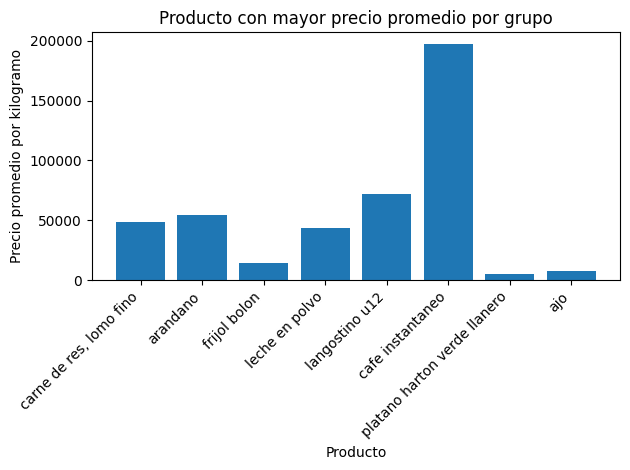

In [14]:
plt.bar(
    productoCaroDelGrupo2026['Producto'],
    productoCaroDelGrupo2026['Precio_Promedio']
)
plt.title('Producto con mayor precio promedio por grupo')
plt.xlabel('Producto')
plt.ylabel('Precio promedio por kilogramo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Conclusión de estudio** La variable del grupo, tiene una alta relacion con la variable producto, aunque no va a ser utilizada para el modelo, es interesante que se pueda llegar a usar, el problema es el modelo puede usar otras variables para llegar más cerca a lo solicitado que es **predecir el precio futuro del producto**

## Estudio de la variable "Mercado" para un estudio de un año

## Análisis de Correlación

Identificar las columnas que tienen mayor impacto sobre mi modelo

**Último paso**: Guardar los datos ya analizados, organizados y listos para entrenar un modelo ML